In [ ]:
# Header of the CSV files
# Date	Time	time_passed_since_start	ADS Reading 1	Current 1	ADS Reading 2	Current 2	ADS Reading 3	Volts 1	Lost Data


In [30]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as curve_fit

In [42]:
# Calibration done from excel. 
# No point doing in python. Values is unique for the board used for data collection. Will change on different board based on resistor values.

def get_calibrated_voltage(reading):
    # y = 439.01x - 2.4315
    x = 439.01
    c = -2.4315
    return (reading - c) / x

In [37]:
current_directory = Path.cwd()
discharge_file_dir = Path.joinpath(current_directory.parent, "Discharge")

files = [f for f in discharge_file_dir.iterdir() if f.is_file()]    # Names are sorted by date already
print(files)

[WindowsPath('f:/Github/Proa-II-Electrical-Setup/Calibration Data 2/Data/Discharge/2026-03-18_data_log.csv'), WindowsPath('f:/Github/Proa-II-Electrical-Setup/Calibration Data 2/Data/Discharge/2026-03-25_data_log.csv'), WindowsPath('f:/Github/Proa-II-Electrical-Setup/Calibration Data 2/Data/Discharge/2026-04-01_data_log.csv'), WindowsPath('f:/Github/Proa-II-Electrical-Setup/Calibration Data 2/Data/Discharge/2026-04-08_data_log.csv')]


In [40]:
def drop_columns(df, columns=['Date', 'Time', 'Current 1', 'Current 2', 'Volts 1', 'Lost Data']):
    return df.drop(columns=columns)

In [ ]:
def median_smoothing(series, window_size=5):
    smoothed_series = []
    for i in range(len(series)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(series), i + window_size // 2 + 1)
        median_value = series[start_index:end_index].median()
        smoothed_series.append(median_value)
    return smoothed_series

def ema_smoothing(series, alpha = 0.6):
    smoothed_series = [series[0]]  # Start with the first value
    for i in range(1, len(series)):
        smoothed_value = alpha * series[i] + (1 - alpha) * smoothed_series[-1]
        smoothed_series.append(smoothed_value)
    return smoothed_series


In [ ]:
def translate_time(time_series):
    prev_interval = 0
    starting_time = time_series.iloc[0]
    
    for i in range(1, len(time_series)):
        if (time_series.iloc[i] < time_series.iloc[i-1]):
            starting_time = time_series.iloc[i]
            prev_interval = time_series.iloc[i-1]
            time_series.iloc[i] = time_series.iloc[i] - starting_time + prev_interval
        else:
            time_series.iloc[i] = time_series.iloc[i] - starting_time + prev_interval
    return time_series

In [49]:
for file in files:
    df = pd.read_csv(file)
    total_lost_data = df['Lost Data'][1:].sum() # Remove first row which accumulates error from waiting to connect
    print("Total Lost Data for file {}: {}".format(file.name, total_lost_data))
    print(df.shape)

Total Lost Data for file 2026-03-18_data_log.csv: 424
(157540, 10)
Total Lost Data for file 2026-03-25_data_log.csv: 3144
(219240, 10)
Total Lost Data for file 2026-04-01_data_log.csv: 12191
(235840, 10)
Total Lost Data for file 2026-04-08_data_log.csv: 0
(6500, 10)


In [108]:
#for file in files:
for file in [files[0]]: # Only read the first file for now
    df = pd.read_csv(file)
    
    cleaned_df = drop_columns(df)
    cleaned_df['Calibrated Voltage'] = cleaned_df['ADS Reading 3'].apply(get_calibrated_voltage)
    print(cleaned_df.head())
    cleaned_df['Median Smoothed ADS 3 (5-point)'] = median_smoothing(cleaned_df['ADS Reading 3'], window_size=5)
    cleaned_df['Median Smoothed ADS 3 (10-point)'] = median_smoothing(cleaned_df['ADS Reading 3'], window_size=10)
    cleaned_df['Smoothed ADS 3 (0.2-point)'] = ema_smoothing(cleaned_df['ADS Reading 3'], alpha=0.2)
    cleaned_df['Smoothed ADS 3 (0.8-point)'] = ema_smoothing(cleaned_df['ADS Reading 3'], alpha=0.8)

   time_passed_since_start  ADS Reading 1  ADS Reading 2  ADS Reading 3  \
0                  2681199            -65            -11          25542   
1                  2681231            -57            -13          25542   
2                  2681263            -54            -13          25540   
3                  2681294            -67            -14          25541   
4                  2681325            -58             -8          25541   

   Calibrated Voltage  
0           58.186446  
1           58.186446  
2           58.181890  
3           58.184168  
4           58.184168  


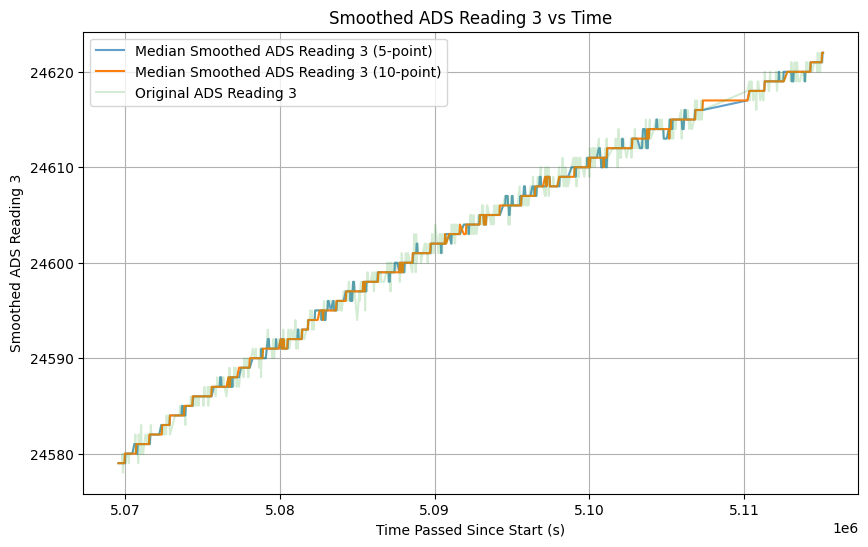

In [114]:
plt.figure(figsize=(10, 6))
plt.plot(cleaned_df['time_passed_since_start'].iloc[48000:49000], cleaned_df['Median Smoothed ADS 3 (5-point)'].iloc[48000:49000], label='Median Smoothed ADS Reading 3 (5-point)', alpha=0.7)
plt.plot(cleaned_df['time_passed_since_start'].iloc[48000:49000], cleaned_df['Median Smoothed ADS 3 (10-point)'].iloc[48000:49000], label='Median Smoothed ADS Reading 3 (10-point)')
plt.plot(cleaned_df['time_passed_since_start'].iloc[48000:49000], cleaned_df['ADS Reading 3'].iloc[48000:49000], label='Original ADS Reading 3', alpha=0.2)
plt.xlabel('Time Passed Since Start (s)')
plt.ylabel('Smoothed ADS Reading 3')
plt.title('Smoothed ADS Reading 3 vs Time')
plt.legend()
plt.grid()

plt.show()

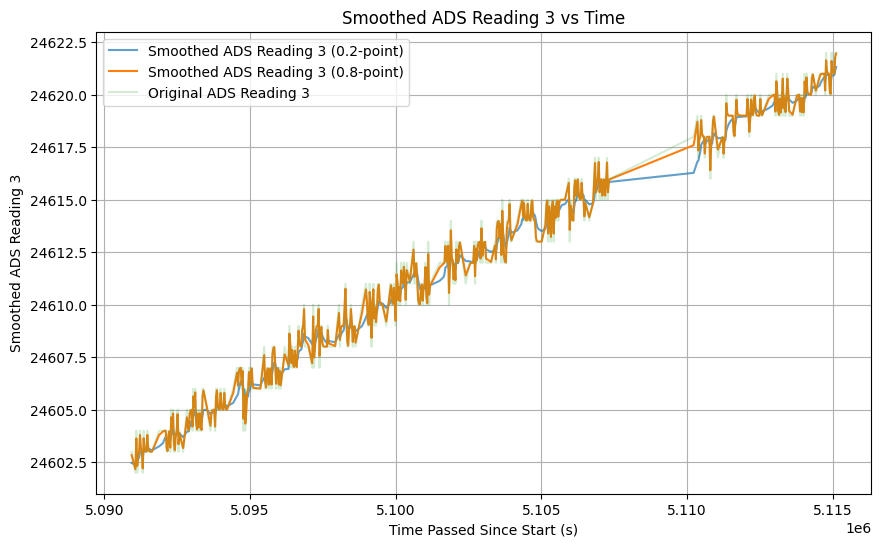

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(cleaned_df['time_passed_since_start'].iloc[48000:49000], cleaned_df['Smoothed ADS 3 (0.2-point)'].iloc[48000:49000], label='Smoothed ADS Reading 3 (0.2-point)', alpha=0.7)
plt.plot(cleaned_df['time_passed_since_start'].iloc[48000:49000], cleaned_df['Smoothed ADS 3 (0.8-point)'].iloc[48000:49000], label='Smoothed ADS Reading 3 (0.8-point)')
plt.plot(cleaned_df['time_passed_since_start'].iloc[48000:49000], cleaned_df['ADS Reading 3'].iloc[48000:49000], label='Original ADS Reading 3', alpha=0.2)
plt.xlabel('Time Passed Since Start (s)')
plt.ylabel('Smoothed ADS Reading 3')
plt.title('Smoothed ADS Reading 3 vs Time')
plt.legend()
plt.grid()

plt.show()